In [ ]:
!pip install optuna ucimlrepo -q

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.6 MB/s eta 0:00:00
Device: cuda


In [ ]:
class NBeatsBlock(nn.Module):
    def __init__(self, input_size, theta_size, horizon,
                 n_layers, hidden_size, basis_function):
        super().__init__()
        self.horizon        = horizon
        self.input_size     = input_size
        self.basis_function = basis_function

        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.ReLU()]
        self.fc_stack = nn.Sequential(*layers)

        self.theta_b = nn.Linear(hidden_size, theta_size, bias=False)
        self.theta_f = nn.Linear(hidden_size, theta_size, bias=False)

    def forward(self, x):
        h        = self.fc_stack(x)
        theta_b  = self.theta_b(h)
        theta_f  = self.theta_f(h)
        backcast = self.basis_function.backcast(theta_b, self.input_size)
        forecast = self.basis_function.forecast(theta_f, self.horizon)
        return backcast, forecast

print('NBeatsBlock defined!')

NBeatsBlock defined!


In [ ]:
class GenericBasis(nn.Module):
    def __init__(self, theta_size, input_size, horizon):
        super().__init__()
        self.W_b = nn.Linear(theta_size, input_size, bias=False)
        self.W_f = nn.Linear(theta_size, horizon,    bias=False)

    def backcast(self, theta, input_size): return self.W_b(theta)
    def forecast(self, theta, horizon):    return self.W_f(theta)


class TrendBasis(nn.Module):
    def __init__(self, degree, input_size, horizon):
        super().__init__()
        t_f = torch.arange(horizon,     dtype=torch.float32) / horizon
        t_b = torch.arange(-input_size, 0, dtype=torch.float32) / horizon
        T_f = torch.stack([t_f ** i for i in range(degree + 1)], dim=1)
        T_b = torch.stack([t_b ** i for i in range(degree + 1)], dim=1)
        self.register_buffer('T_f', T_f)
        self.register_buffer('T_b', T_b)

    def backcast(self, theta, input_size): return theta @ self.T_b.T
    def forecast(self, theta, horizon):    return theta @ self.T_f.T


class SeasonalityBasis(nn.Module):
    def __init__(self, input_size, horizon):
        super().__init__()
        half  = horizon // 2
        freqs = torch.arange(1, half, dtype=torch.float32)

        t_f   = torch.arange(horizon, dtype=torch.float32) / horizon
        cos_f = torch.cos(2 * torch.pi * freqs[:, None] * t_f[None, :])
        sin_f = torch.sin(2 * torch.pi * freqs[:, None] * t_f[None, :])
        S_f   = torch.cat([torch.ones(1, horizon), cos_f, sin_f], dim=0)
        self.register_buffer('S_f', S_f)

        t_b   = torch.arange(-input_size, 0, dtype=torch.float32) / horizon
        cos_b = torch.cos(2 * torch.pi * freqs[:, None] * t_b[None, :])
        sin_b = torch.sin(2 * torch.pi * freqs[:, None] * t_b[None, :])
        S_b   = torch.cat([torch.ones(1, input_size), cos_b, sin_b], dim=0)
        self.register_buffer('S_b', S_b)

        self.n_params = S_f.shape[0]

    def backcast(self, theta, input_size): return theta @ self.S_b
    def forecast(self, theta, horizon):    return theta @ self.S_f

print('Basis functions defined!')

Basis functions defined!


In [ ]:
class NBeatsStack(nn.Module):
    def __init__(self, blocks):
        super().__init__()
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        stack_forecast = 0.0
        for block in self.blocks:
            backcast, forecast = block(x)
            x              = x - backcast
            stack_forecast = stack_forecast + forecast
        return x, stack_forecast

print('NBeatsStack defined!')

NBeatsStack defined!


In [ ]:
class NBeatsGeneric(nn.Module):
    def __init__(self, input_size, horizon, n_stacks=10,
                 n_blocks=1, n_layers=4, hidden_size=256):
        super().__init__()
        theta_size = hidden_size
        stacks = []
        for _ in range(n_stacks):
            blocks = []
            for _ in range(n_blocks):
                basis = GenericBasis(theta_size, input_size, horizon)
                block = NBeatsBlock(input_size, theta_size, horizon,
                                    n_layers, hidden_size, basis)
                blocks.append(block)
            stacks.append(NBeatsStack(blocks))
        self.stacks = nn.ModuleList(stacks)

    def forward(self, x):
        global_forecast = 0.0
        for stack in self.stacks:
            x, sf           = stack(x)
            global_forecast = global_forecast + sf
        return global_forecast


class NBeatsInterpretable(nn.Module):
    def __init__(self, input_size, horizon, trend_blocks=3,
                 season_blocks=3, trend_layers=4, season_layers=4,
                 trend_hidden=512, season_hidden=1024, degree=2):
        super().__init__()
        trend_basis      = TrendBasis(degree, input_size, horizon)
        shared_trend     = NBeatsBlock(input_size, degree + 1, horizon,
                                       trend_layers, trend_hidden, trend_basis)
        self.trend_stack = NBeatsStack([shared_trend] * trend_blocks)

        season_basis      = SeasonalityBasis(input_size, horizon)
        shared_season     = NBeatsBlock(input_size, season_basis.n_params,
                                        horizon, season_layers,
                                        season_hidden, season_basis)
        self.season_stack = NBeatsStack([shared_season] * season_blocks)

    def forward(self, x):
        x, trend  = self.trend_stack(x)
        _, season = self.season_stack(x)
        return trend + season, trend, season

print('NBeats models defined!')

NBeats models defined!


In [ ]:
class MultivariateLSTM(nn.Module):
    def __init__(self, n_features, hidden_size,
                 num_layers, horizon, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        batch = x.shape[0]
        x     = x.view(batch, WINDOW, n_features)
        out, _      = self.lstm(x)
        last        = self.dropout(out[:, -1, :])
        return self.fc(last)

print('LSTM defined!')

LSTM defined!


In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "sid321axn/beijing-multisite-airquality-data-set"
)

print("Path to dataset files:", path)

100%|██████████| 8.58M/8.58M [00:00<00:00, 65.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sid321axn/beijing-multisite-airquality-data-set/versions/1


In [ ]:
import pandas as pd
import os

file = os.path.join(
    path,
    "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
)

df_raw= pd.read_csv(file)

print(df_raw.shape)
df_raw.head()

(35064, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [ ]:
feature_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO',
                'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']
available    = [c for c in feature_cols if c in df_raw.columns]
df = df_raw[available].copy()

df = df.dropna(subset=['PM2.5'])
df = df.ffill().bfill()
df = df.iloc[:35000].reset_index(drop=True)

print('Final shape  :', df.shape)
print('Features used:', available)
print('Missing values:', df.isnull().sum().sum())
df.describe().round(2)

Final shape  : (34139, 10)
Features used: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'WSPM']
Missing values: 0


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,WSPM
count,34139.00,34139.00,34139.00,34139.00,34139.00,34139.00,34139.00,34139.00,34139.00,34139.0
mean,82.77,110.12,17.46,59.43,1266.59,55.40,13.67,1011.75,3.27,1.7
std,82.14,95.46,22.89,37.09,1250.52,57.61,11.38,10.37,13.65,1.2
min,3.00,2.00,0.29,2.00,100.00,0.21,-16.80,985.90,-35.30,0.0
25%,22.00,38.00,3.00,30.00,500.00,7.00,3.30,1003.20,-7.90,0.9
50%,58.00,87.00,9.00,54.00,900.00,41.00,14.70,1011.20,4.00,1.4
75%,114.00,155.00,21.00,82.00,1600.00,81.00,23.30,1020.00,15.70,2.2
max,898.00,984.00,341.00,290.00,10000.00,423.00,40.50,1042.00,28.50,11.2


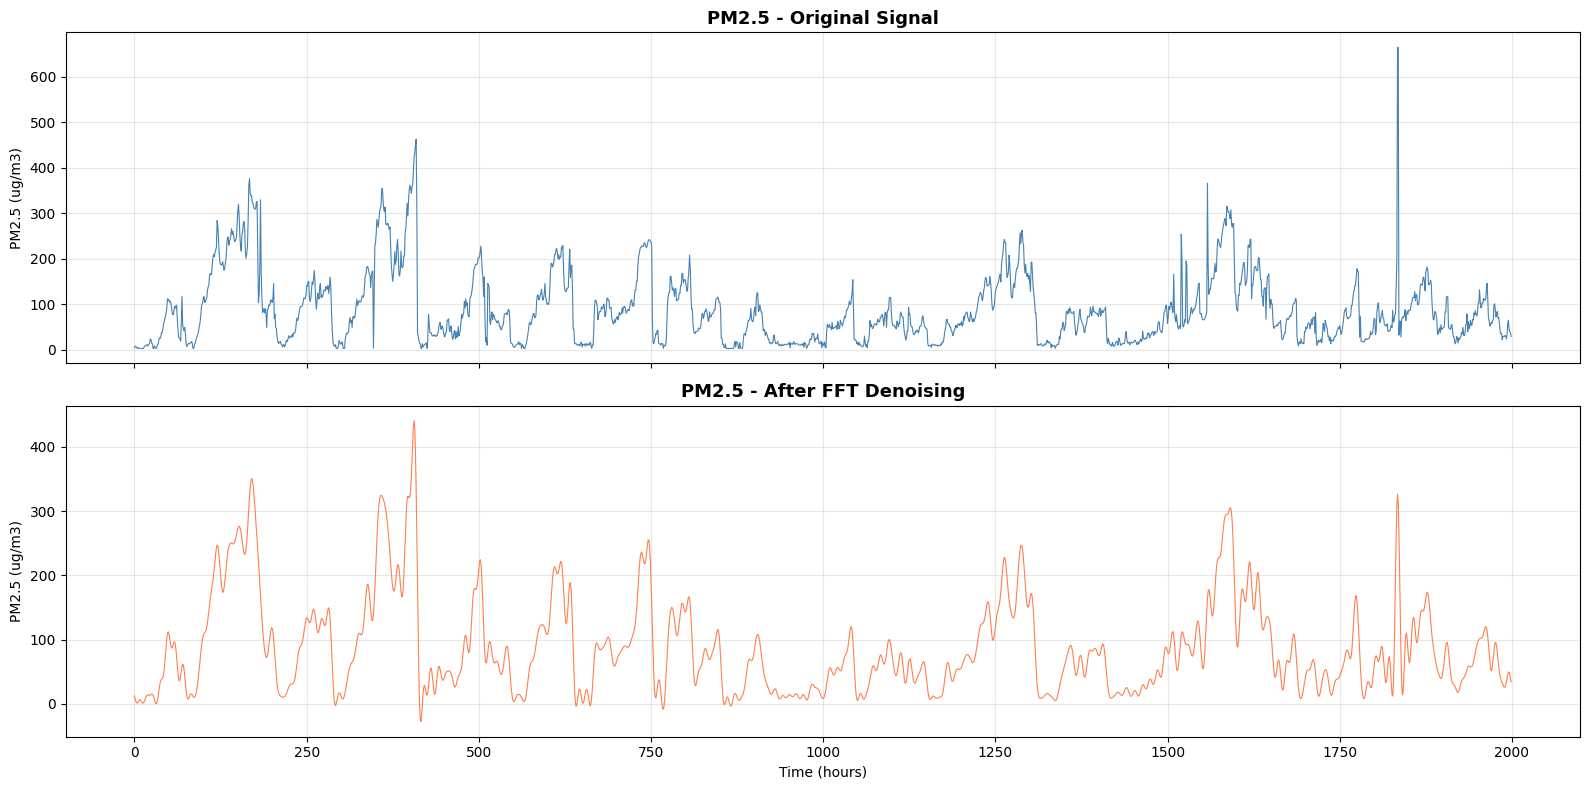

FFT denoising done!


In [ ]:
def fft_denoise(signal, keep_ratio=0.1):
    fft_vals  = np.fft.fft(signal)
    n         = len(fft_vals)
    n_keep    = int(n * keep_ratio)
    fft_clean = fft_vals.copy()
    fft_clean[n_keep : n - n_keep] = 0
    return np.fft.ifft(fft_clean).real


pm25_original = df['PM2.5'].values.astype(np.float32)
pm25_denoised = fft_denoise(pm25_original, keep_ratio=0.1).astype(np.float32)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(pm25_original[:2000], color='steelblue', linewidth=0.8)
axes[0].set_title('PM2.5 - Original Signal', fontsize=13, fontweight='bold')
axes[0].set_ylabel('PM2.5 (ug/m3)'); axes[0].grid(True, alpha=0.3)

axes[1].plot(pm25_denoised[:2000], color='coral', linewidth=0.8)
axes[1].set_title('PM2.5 - After FFT Denoising', fontsize=13, fontweight='bold')
axes[1].set_ylabel('PM2.5 (ug/m3)')
axes[1].set_xlabel('Time (hours)'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fft_denoising.png', dpi=150, bbox_inches='tight')
plt.show()
print('FFT denoising done!')

In [ ]:
df['PM2.5'] = pm25_denoised

data_np   = df.values.astype(np.float32)
data_mean = data_np.mean(axis=0)
data_std  = data_np.std(axis=0) + 1e-8
data_norm = (data_np - data_mean) / data_std

target_idx = 0
n_features = data_norm.shape[1]
WINDOW     = 96
HORIZON    = 8

print('Features      :', n_features)
print('Window size   :', WINDOW, 'hours')
print('Horizon       :', HORIZON, 'hours')


class MultivariateWindowDataset(Dataset):
    def __init__(self, data, window, horizon, target_idx=0):
        self.data       = torch.tensor(data, dtype=torch.float32)
        self.window     = window
        self.horizon    = horizon
        self.target_idx = target_idx
        self.n          = len(data) - window - horizon + 1

    def __len__(self): return self.n

    def __getitem__(self, i):
        x = self.data[i : i + self.window].flatten()
        y = self.data[i + self.window : i + self.window + self.horizon,
                      self.target_idx]
        return x, y


n        = len(data_norm)
n_train  = int(n * 0.70)
n_val    = int(n * 0.15)

train_data = data_norm[:n_train]
val_data   = data_norm[n_train - WINDOW : n_train + n_val]
test_data  = data_norm[n_train + n_val - WINDOW :]

train_ds = MultivariateWindowDataset(train_data, WINDOW, HORIZON)
val_ds   = MultivariateWindowDataset(val_data,   WINDOW, HORIZON)
test_ds  = MultivariateWindowDataset(test_data,  WINDOW, HORIZON)

mv_train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
mv_val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

MV_INPUT = WINDOW * n_features
print('Flattened input size :', MV_INPUT)
print('Train/Val/Test       :',
      len(train_ds), '/', len(val_ds), '/', len(test_ds))

Features      : 10
Window size   : 96 hours
Horizon       : 8 hours
Flattened input size : 960
Train/Val/Test       : 23794 / 5113 / 5115


In [ ]:
def train_model_mv(model, train_loader, val_loader,
                   epochs=30, lr=1e-3, wd=1e-4):
    opt       = torch.optim.Adam(model.parameters(),
                                 lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt, T_max=epochs)
    criterion = nn.MSELoss()
    train_hist, val_hist = [], []

    for epoch in range(epochs):
        model.train()
        t_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            if isinstance(pred, tuple): pred = pred[0]
            loss = criterion(pred, yb)
            loss.backward(); opt.step()
            t_loss += loss.item()
        scheduler.step()
        train_hist.append(t_loss / len(train_loader))

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                if isinstance(pred, tuple): pred = pred[0]
                v_loss += criterion(pred, yb).item()
        val_hist.append(v_loss / len(val_loader))

        if (epoch + 1) % 10 == 0:
            print('  Epoch', epoch+1, '/', epochs,
                  '| Train =', round(train_hist[-1], 4),
                  '| Val =',   round(val_hist[-1],   4))

    return train_hist, val_hist


def evaluate_mv(model, test_ds, data_mean, data_std, target_idx=0):
    model.eval()
    preds, actuals = [], []
    pm25_mean = data_mean[target_idx]
    pm25_std  = data_std[target_idx]

    with torch.no_grad():
        for i in range(len(test_ds)):
            xb, yb = test_ds[i]
            xb     = xb.unsqueeze(0).to(device)
            pred   = model(xb)
            if isinstance(pred, tuple): pred = pred[0]
            preds.append(pred.squeeze().cpu().numpy()
                         * pm25_std + pm25_mean)
            actuals.append(yb.numpy() * pm25_std + pm25_mean)

    preds   = np.array(preds)
    actuals = np.array(actuals)
    mae_v   = np.mean(np.abs(preds - actuals))
    rmse_v  = np.sqrt(np.mean((preds - actuals) ** 2))
    mape_v  = np.mean(np.abs((preds - actuals) /
              (np.abs(actuals) + 1e-8))) * 100
    smape_v = np.mean(200 * np.abs(preds - actuals) /
              (np.abs(preds) + np.abs(actuals) + 1e-8))
    return preds, actuals, mae_v, rmse_v, mape_v, smape_v

print('Helper functions defined!')

Helper functions defined!


In [ ]:
def mv_nbeats_objective(trial):
    params = {
        'n_stacks'    : trial.suggest_int('n_stacks',    3, 15),
        'n_layers'    : trial.suggest_int('n_layers',    2,  5),
        'hidden_size' : trial.suggest_categorical('hidden_size',
                        [128, 256, 512]),
        'lr'          : trial.suggest_float('lr',
                        1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay',
                        1e-6, 1e-3, log=True),
    }
    model = NBeatsGeneric(
        input_size  = MV_INPUT, horizon = HORIZON,
        n_stacks    = params['n_stacks'], n_blocks = 1,
        n_layers    = params['n_layers'],
        hidden_size = params['hidden_size']
    ).to(device)

    opt       = torch.optim.Adam(model.parameters(),
                lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)
    criterion = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for xb, yb in mv_train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in mv_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item()
    return val_loss / len(mv_val_loader)


print('Bayesian Optimization for N-BEATS Generic (20 trials)...')
mv_nbeats_study = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=42),
    pruner    = optuna.pruners.MedianPruner()
)
mv_nbeats_study.optimize(mv_nbeats_objective, n_trials=20,
                          show_progress_bar=True)
print('Best Val MSE :', round(mv_nbeats_study.best_value, 4))
print('Best Params  :', mv_nbeats_study.best_params)

Bayesian Optimization for N-BEATS Generic (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

[W 2026-04-12 08:49:38,273] Trial 19 failed with parameters: {'n_stacks': 6, 'n_layers': 4, 'hidden_size': 256, 'lr': 0.007501054462493079, 'weight_decay': 0.0002550146706904572} because of the following error: The value nan is not acceptable.
[W 2026-04-12 08:49:38,275] Trial 19 failed with value nan.
Best Val MSE : 0.3258
Best Params  : {'n_stacks': 8, 'n_layers': 3, 'hidden_size': 256, 'lr': 0.0030939544752072385, 'weight_decay': 0.0009594135892723404}


In [ ]:
def mv_lstm_objective(trial):
    params = {
        'hidden_size' : trial.suggest_categorical('hidden_size',
                        [64, 128, 256, 512]),
        'num_layers'  : trial.suggest_int('num_layers', 1, 3),
        'dropout'     : trial.suggest_float('dropout',  0.0, 0.5),
        'lr'          : trial.suggest_float('lr',
                        1e-4, 1e-2, log=True),
        'weight_decay': trial.suggest_float('weight_decay',
                        1e-6, 1e-3, log=True),
    }
    model = MultivariateLSTM(
        n_features  = n_features,
        hidden_size = params['hidden_size'],
        num_layers  = params['num_layers'],
        horizon     = HORIZON,
        dropout     = params['dropout']
    ).to(device)

    opt       = torch.optim.Adam(model.parameters(),
                lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)
    criterion = nn.MSELoss()

    for epoch in range(15):
        model.train()
        for xb, yb in mv_train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            criterion(model(xb), yb).backward()
            opt.step()
        scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in mv_val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item()
    return val_loss / len(mv_val_loader)


print('Bayesian Optimization for LSTM (20 trials)...')
mv_lstm_study = optuna.create_study(
    direction = 'minimize',
    sampler   = optuna.samplers.TPESampler(seed=42),
    pruner    = optuna.pruners.MedianPruner()
)
mv_lstm_study.optimize(mv_lstm_objective, n_trials=20,
                        show_progress_bar=True)
print('Best Val MSE :', round(mv_lstm_study.best_value, 4))
print('Best Params  :', mv_lstm_study.best_params)

Bayesian Optimization for LSTM (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best Val MSE : 0.0304
Best Params  : {'hidden_size': 512, 'num_layers': 3, 'dropout': 0.009150850632174736, 'lr': 0.0008225379742839298, 'weight_decay': 1.0109751147185862e-06}


In [ ]:
bp_nb = mv_nbeats_study.best_params
bp_ls = mv_lstm_study.best_params

# N-BEATS Generic
print('Training final N-BEATS Generic...')
final_mv_nbeats_g = NBeatsGeneric(
    input_size  = MV_INPUT, horizon     = HORIZON,
    n_stacks    = bp_nb['n_stacks'], n_blocks = 1,
    n_layers    = bp_nb['n_layers'],
    hidden_size = bp_nb['hidden_size']
).to(device)
hist_ng_tr, hist_ng_val = train_model_mv(
    final_mv_nbeats_g, mv_train_loader, mv_val_loader,
    epochs=30, lr=bp_nb['lr'], wd=bp_nb['weight_decay'])

# N-BEATS Interpretable
print('\nTraining final N-BEATS Interpretable...')
final_mv_nbeats_i = NBeatsInterpretable(
    input_size    = MV_INPUT, horizon       = HORIZON,
    trend_blocks  = 3,        season_blocks = 3,
    trend_layers  = 4,        season_layers = 4,
    trend_hidden  = 512,      season_hidden = 1024,
    degree        = 2
).to(device)
hist_ni_tr, hist_ni_val = train_model_mv(
    final_mv_nbeats_i, mv_train_loader, mv_val_loader,
    epochs=30, lr=bp_nb['lr'], wd=bp_nb['weight_decay'])

# LSTM
print('\nTraining final LSTM...')
final_mv_lstm = MultivariateLSTM(
    n_features  = n_features,
    hidden_size = bp_ls['hidden_size'],
    num_layers  = bp_ls['num_layers'],
    horizon     = HORIZON,
    dropout     = bp_ls['dropout']
).to(device)
hist_ls_tr, hist_ls_val = train_model_mv(
    final_mv_lstm, mv_train_loader, mv_val_loader,
    epochs=30, lr=bp_ls['lr'], wd=bp_ls['weight_decay'])

Training final N-BEATS Generic...
  Epoch 10 / 30 | Train = 0.1453 | Val = 0.3613
  Epoch 20 / 30 | Train = 0.0729 | Val = 0.3319
  Epoch 30 / 30 | Train = 0.0345 | Val = 0.3661

Training final N-BEATS Interpretable...
  Epoch 10 / 30 | Train = 3.4261628953879276e+29 | Val = 4.2327454907413554e+29
  Epoch 20 / 30 | Train = 3.4252308805065854e+29 | Val = 4.2327454907413554e+29
  Epoch 30 / 30 | Train = 3.42536423556603e+29 | Val = 4.2327454907413554e+29

Training final LSTM...
  Epoch 10 / 30 | Train = 0.0492 | Val = 0.0636
  Epoch 20 / 30 | Train = 0.0176 | Val = 0.0361
  Epoch 30 / 30 | Train = 0.0072 | Val = 0.0293


In [ ]:
p_ng, a_ng, mae_ng, rmse_ng, mape_ng, smape_ng = evaluate_mv(
    final_mv_nbeats_g, test_ds, data_mean, data_std)
p_ni, a_ni, mae_ni, rmse_ni, mape_ni, smape_ni = evaluate_mv(
    final_mv_nbeats_i, test_ds, data_mean, data_std)
p_ls, a_ls, mae_ls, rmse_ls, mape_ls, smape_ls = evaluate_mv(
    final_mv_lstm, test_ds, data_mean, data_std)

results = pd.DataFrame({
    'Model'  : ['LSTM', 'N-BEATS Generic', 'N-BEATS Interpretable'],
    'MAE'    : [mae_ls,   mae_ng,   mae_ni],
    'RMSE'   : [rmse_ls,  rmse_ng,  rmse_ni],
    'MAPE'   : [mape_ls,  mape_ng,  mape_ni],
    'sMAPE'  : [smape_ls, smape_ng, smape_ni],
}).round(4)

print('\n===== PM2.5 BENCHMARK (with Bayesian Tuning) =====')
print(results.to_string(index=False))
print('==================================================')


===== PM2.5 BENCHMARK (with Bayesian Tuning) =====
                Model          MAE         RMSE         MAPE      sMAPE
                 LSTM 5.496800e+00 1.407360e+01 9.854630e+01  12.298000
      N-BEATS Generic 2.731300e+01 4.861140e+01 4.273098e+02  43.008701
N-BEATS Interpretable 4.019398e+16 5.200834e+16 1.509028e+18 200.000000


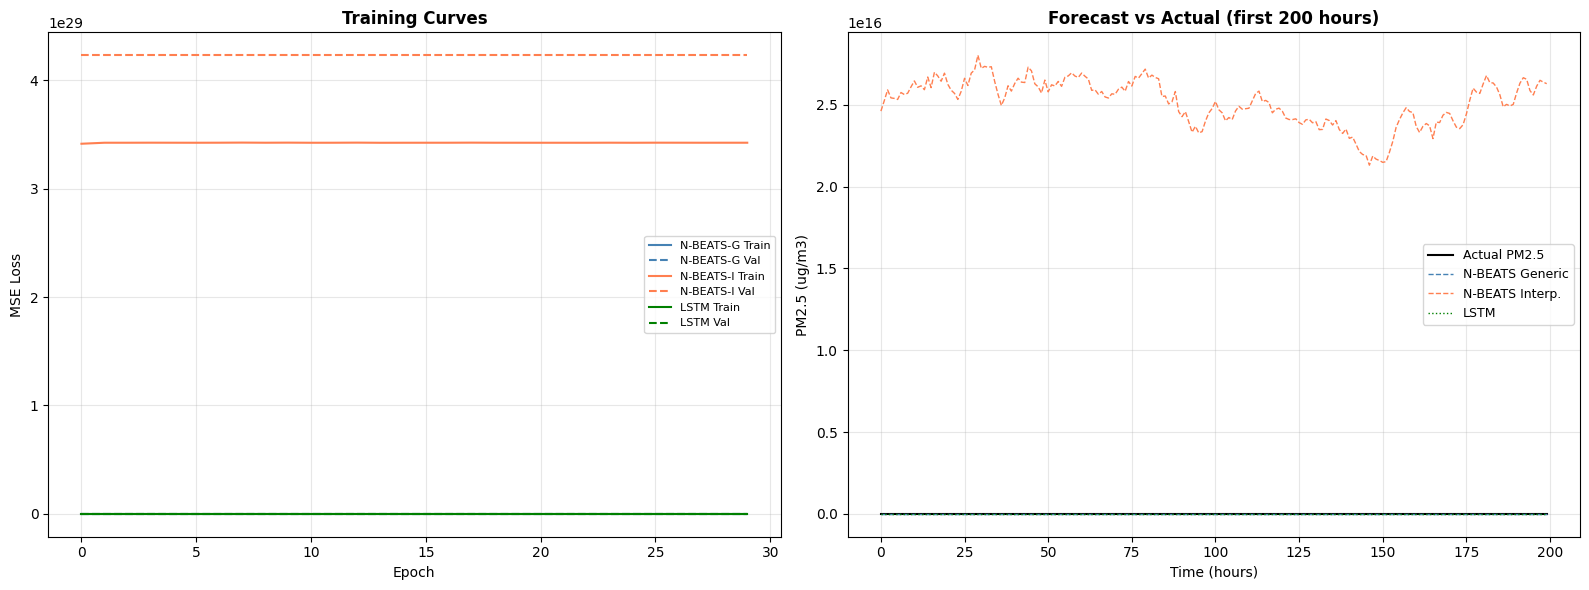

Saved: mv_benchmark.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training curves
axes[0].plot(hist_ng_tr,  color='steelblue', label='N-BEATS-G Train')
axes[0].plot(hist_ng_val, color='steelblue', linestyle='--',
             label='N-BEATS-G Val')
axes[0].plot(hist_ni_tr,  color='coral',     label='N-BEATS-I Train')
axes[0].plot(hist_ni_val, color='coral',     linestyle='--',
             label='N-BEATS-I Val')
axes[0].plot(hist_ls_tr,  color='green',     label='LSTM Train')
axes[0].plot(hist_ls_val, color='green',     linestyle='--',
             label='LSTM Val')
axes[0].set_title('Training Curves', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Forecast vs Actual
n_show = 200
axes[1].plot(a_ng[:n_show, 0], color='black',     linewidth=1.5,
             label='Actual PM2.5')
axes[1].plot(p_ng[:n_show, 0], color='steelblue', linewidth=1.0,
             linestyle='--', label='N-BEATS Generic')
axes[1].plot(p_ni[:n_show, 0], color='coral',     linewidth=1.0,
             linestyle='--', label='N-BEATS Interp.')
axes[1].plot(p_ls[:n_show, 0], color='green',     linewidth=1.0,
             linestyle=':',  label='LSTM')
axes[1].set_title('Forecast vs Actual (first 200 hours)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('PM2.5 (ug/m3)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mv_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mv_benchmark.png')

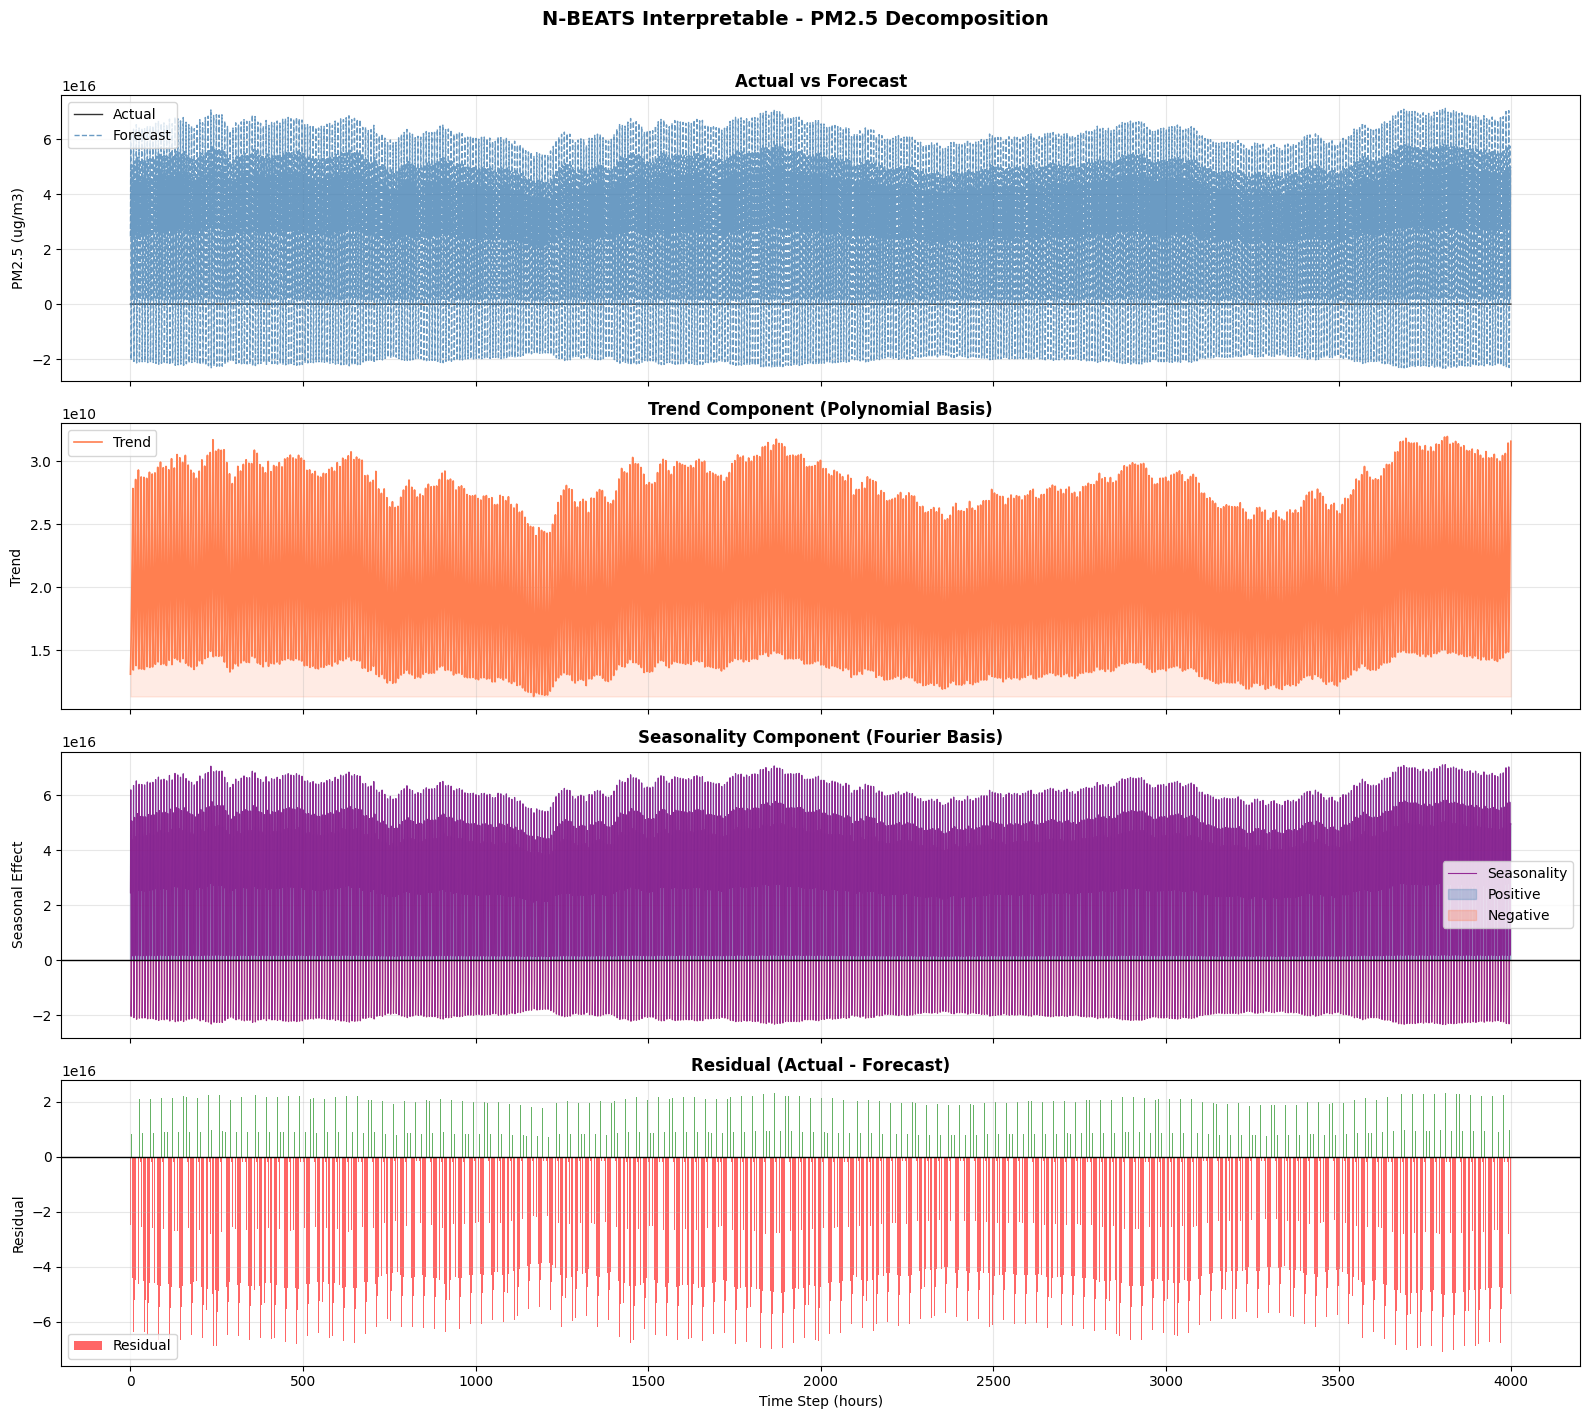

Saved: pm25_decomposition.png


In [ ]:
final_mv_nbeats_i.eval()
trends, seasons, forecasts, actuals = [], [], [], []
pm25_mean_v = data_mean[0]
pm25_std_v  = data_std[0]

with torch.no_grad():
    for i in range(min(500, len(test_ds))):
        xb, yb = test_ds[i]
        xb     = xb.unsqueeze(0).to(device)
        forecast, trend, season = final_mv_nbeats_i(xb)
        forecasts.append(forecast.squeeze().cpu().numpy()
                         * pm25_std_v + pm25_mean_v)
        trends.append(trend.squeeze().cpu().numpy()
                      * pm25_std_v + pm25_mean_v)
        seasons.append(season.squeeze().cpu().numpy() * pm25_std_v)
        actuals.append(yb.numpy() * pm25_std_v + pm25_mean_v)

forecasts = np.array(forecasts)
trends    = np.array(trends)
seasons   = np.array(seasons)
actuals   = np.array(actuals)

flat_fc  = forecasts.flatten()
flat_tr  = trends.flatten()
flat_se  = seasons.flatten()
flat_ac  = actuals.flatten()
t_ax     = np.arange(len(flat_fc))

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(t_ax, flat_ac, color='black',     linewidth=1.0,
             label='Actual', alpha=0.8)
axes[0].plot(t_ax, flat_fc, color='steelblue', linewidth=1.0,
             linestyle='--', label='Forecast', alpha=0.8)
axes[0].set_ylabel('PM2.5 (ug/m3)')
axes[0].set_title('Actual vs Forecast', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ax, flat_tr, color='coral', linewidth=1.2, label='Trend')
axes[1].fill_between(t_ax, flat_tr.min(), flat_tr,
                     alpha=0.15, color='coral')
axes[1].set_ylabel('Trend')
axes[1].set_title('Trend Component (Polynomial Basis)',
                  fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(t_ax, flat_se, color='purple', linewidth=0.8,
             label='Seasonality', alpha=0.8)
axes[2].fill_between(t_ax, 0, flat_se, where=(flat_se >= 0),
                     alpha=0.3, color='steelblue', label='Positive')
axes[2].fill_between(t_ax, 0, flat_se, where=(flat_se < 0),
                     alpha=0.3, color='coral', label='Negative')
axes[2].axhline(y=0, color='black', linewidth=1.0)
axes[2].set_ylabel('Seasonal Effect')
axes[2].set_title('Seasonality Component (Fourier Basis)',
                  fontsize=12, fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

residual = flat_ac - flat_fc
axes[3].bar(t_ax, residual,
            color=['green' if r >= 0 else 'red' for r in residual],
            alpha=0.6, label='Residual')
axes[3].axhline(y=0, color='black', linewidth=1.0)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Time Step (hours)')
axes[3].set_title('Residual (Actual - Forecast)',
                  fontsize=12, fontweight='bold')
axes[3].legend(); axes[3].grid(True, alpha=0.3)

plt.suptitle('N-BEATS Interpretable - PM2.5 Decomposition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pm25_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_decomposition.png')